<a href="https://colab.research.google.com/github/lazic7/MSAP/blob/master/LV1_ponavljanje.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

**Učitavanje i čišćenje podataka**

In [3]:
df = pd.read_csv('processed_data2.csv')

#Prikaz prvih i zadnjih 5 redaka služi za brzi uvid u strukturu podataka, nazive varijabli i tipove vrijednosti.
df.head()

,phone_brand,phone_model,store,price_usd,storage,ram,launch_date,dimensions,weight,display_type,...,price_range,os_type,os_version,battery_size,colors_available,chip_company,cpu_core,gpu_company,fingerprint,video_resolution
0,apple,Apple iPhone 16 Pro,Amazon DE,1357.55,256,8,2024-09-20,149.6 x 71.5 x 8.3 mm (5.89 x 2.81 x 0.33 in),199.0,"LTPO Super Retina XDR OLED, 120Hz, HDR10, Dolb...",...,medium price,iOS,18,Medium,4,Apple,Hexa-core,Apple,Face,4K
1,apple,Apple iPhone 16 Pro,Amazon DE,1492.55,512,8,2024-09-20,149.6 x 71.5 x 8.3 mm (5.89 x 2.81 x 0.33 in),199.0,"LTPO Super Retina XDR OLED, 120Hz, HDR10, Dolb...",...,high price,iOS,18,Medium,4,Apple,Hexa-core,Apple,Face,4K
2,apple,Apple iPhone 16 Pro,Amazon DE,1705.32,1000,8,2024-09-20,149.6 x 71.5 x 8.3 mm (5.89 x 2.81 x 0.33 in),199.0,"LTPO Super Retina XDR OLED, 120Hz, HDR10, Dolb...",...,high price,iOS,18,Medium,4,Apple,Hexa-core,Apple,Face,4K
3,apple,Apple iPhone 16 Pro Max,Amazon DE,1564.92,512,8,2024-09-20,163 x 77.6 x 8.3 mm (6.42 x 3.06 x 0.33 in),227.0,"LTPO Super Retina XDR OLED, 120Hz, HDR10, Dolb...",...,high price,iOS,18,Large,4,Apple,Hexa-core,Apple,Face,4K
4,apple,Apple iPhone 12 mini,Amazon DE,247.32,128,4,2020-11-13,131.5 x 64.2 x 7.4 mm (5.18 x 2.53 x 0.29 in),135.0,"Super Retina XDR OLED, HDR10, Dolby Vision, 62...",...,medium price,iOS,14.1,Small,6,Apple,Hexa-core,Apple,Face,4K


In [4]:
df.tail()

,phone_brand,phone_model,store,price_usd,storage,ram,launch_date,dimensions,weight,display_type,...,price_range,os_type,os_version,battery_size,colors_available,chip_company,cpu_core,gpu_company,fingerprint,video_resolution
1703,xiaomi,Xiaomi Redmi Note 10S,AliExpress,156.00,128,4,2021-04-28,160.5 x 74.5 x 8.3 mm (6.32 x 2.93 x 0.33 in),178.8,"AMOLED, 450 nits (typ), 1100 nits (peak)",...,medium price,Android,11,Large,3,Mediatek,Octa-core,Mali,side,4K
1704,xiaomi,Xiaomi Redmi Note 10S,AliExpress,145.35,128,6,2021-04-28,160.5 x 74.5 x 8.3 mm (6.32 x 2.93 x 0.33 in),178.8,"AMOLED, 450 nits (typ), 1100 nits (peak)",...,medium price,Android,11,Large,3,Mediatek,Octa-core,Mali,side,4K
1705,xiaomi,Xiaomi Redmi Note 11 Pro,AliExpress,161.00,128,6,2022-02-18,164.2 x 76.1 x 8.1 mm (6.46 x 3.00 x 0.32 in),202.0,"Super AMOLED, 120Hz, 700 nits, 1200 nits (peak)",...,medium price,Android,11,Large,3,Mediatek,Octa-core,Mali,side,1080p
1706,xiaomi,Xiaomi 11 Lite 5G NE,AliExpress,266.66,128,8,2021-10-02,160.5 x 75.7 x 6.8 mm (6.32 x 2.98 x 0.27 in),158.0,"AMOLED, 1B colors, Dolby Vision, HDR10+, 90Hz,...",...,medium price,Android,11,Medium,4,Qualcomm,Octa-core,Adreno,side,4K
1707,zte,ZTE nubia Red Magic 6,AliExpress,515.00,128,12,2021-03-11,169.9 x 77.2 x 9.7 mm (6.69 x 3.04 x 0.38 in),220.0,"AMOLED, 1B colors, 165Hz, 630 nits (typ)",...,medium price,Android,11,Large,2,Qualcomm,Octa-core,Adreno,under,8K


In [5]:
#Naredba daje tipove varijabli
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1708 entries, 0 to 1707
Data columns (total 38 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   phone_brand         1708 non-null   object 
 1   phone_model         1708 non-null   object 
 2   store               1708 non-null   object 
 3   price_usd           1708 non-null   float64
 4   storage             1708 non-null   int64  
 5   ram                 1708 non-null   int64  
 6   launch_date         1708 non-null   object 
 7   dimensions          1708 non-null   object 
 8   weight              1708 non-null   float64
 9   display_type        1708 non-null   object 
 10  display_size        1708 non-null   float64
 11  display_resolution  1708 non-null   object 
 12  os                  1708 non-null   object 
 13  nfc                 1708 non-null   int64  
 14  usb                 1708 non-null   object 
 15  battery             1708 non-null   int64  
 16  featur

In [6]:
df.shape

(1708, 38)

Skup podataka sadrži 1708 redaka i 38 varijabli.

In [7]:
df.isnull().sum()

,0
phone_brand,0
phone_model,0
store,0
price_usd,0
storage,0
ram,0
launch_date,0
dimensions,0
weight,0
display_type,0


Postoje nedostajuće vrijednosti za varijable cpu_core i gpu_company, ali te varijable ne analiziram i redove neću brisati zato što će mi ti redovi koristiti prilikom analize drugih varijabli.

Redci se brišu naredbom df = df.dropna()

In [8]:
df.duplicated().sum()

np.int64(0)

Nema dupliciranih redova.

Duplicirani redci se brisu naredbom df = df.drop_duplicates()

**Eksplorativna analiza podataka (EDA)**

In [9]:
df.describe()

,price_usd,storage,ram,weight,display_size,nfc,battery,foldable,ppi_density,quantile_10,quantile_50,quantile_90,colors_available
count,1708.000000,1708.000000,1708.000000,1708.000000,1708.000000,1708.000000,1708.000000,1708.000000,1708.000000,1708.000000,1708.000000,1708.000000,1708.000000
mean,419.983156,271.798595,7.981265,195.203769,6.564754,0.917447,4657.326698,0.048595,403.826112,125.729804,313.998214,854.838389,3.767564
std,361.680703,207.513099,3.425618,24.738661,0.383238,0.275286,694.689807,0.215082,71.794438,17.976906,113.940350,298.836329,1.551824
min,52.630000,32.000000,2.000000,135.000000,4.700000,0.000000,1821.000000,0.000000,179.000000,100.800000,196.810000,224.154000,1.000000
25%,167.562500,128.000000,6.000000,183.500000,6.500000,1.000000,4500.000000,0.000000,393.000000,114.990000,246.270000,581.990000,3.000000
50%,278.835000,256.000000,8.000000,193.500000,6.600000,1.000000,5000.000000,0.000000,402.000000,118.514000,249.990000,790.560000,3.000000
75%,550.327500,256.000000,12.000000,204.000000,6.700000,1.000000,5000.000000,0.000000,446.000000,127.030000,329.990000,999.990000,4.000000
max,2353.820000,1000.000000,24.000000,627.000000,12.400000,1.000000,10200.000000,1.000000,643.000000,169.706000,550.450000,1375.350000,11.000000


Statistički sažetak (describe) daje osnovne informacije svih numeričkih varijabli.

In [10]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numeričke varijable:")
print(numerical_cols)

print("\nKategorijske varijable:")
print(categorical_cols)

Numeričke varijable:
Index(['price_usd', 'storage', 'ram', 'weight', 'display_size', 'nfc',
       'battery', 'foldable', 'ppi_density', 'quantile_10', 'quantile_50',
       'quantile_90', 'colors_available'],
      dtype='object')

Kategorijske varijable:
Index(['phone_brand', 'phone_model', 'store', 'launch_date', 'dimensions',
       'display_type', 'display_resolution', 'os', 'usb', 'features_sensors',
       'colors', 'video', 'chipset', 'cpu', 'gpu', 'year', 'price_range',
       'os_type', 'os_version', 'battery_size', 'chip_company', 'cpu_core',
       'gpu_company', 'fingerprint', 'video_resolution'],
      dtype='object')


In [11]:
df[categorical_cols].nunique().sort_values()
#df['NAZIV_VARIJABLE'].value_counts() za jednu varijablu
#df_selected=df[["price_usd", "ram", "storage", "battery"]]

,0
video_resolution,3
price_range,3
os_type,4
cpu_core,4
battery_size,5
gpu_company,5
fingerprint,6
store,8
year,8
chip_company,9


Analiza jedinstvenih vrijednosti omogućuje uvid u strukturu kategorijskih varijabli i raspodjelu opažanja po kategorijama.

In [12]:
df_selected=df[["price_usd", "ram", "storage", "battery"]]
df_selected.median() #sredisnja vrijednost

,0
price_usd,278.835
ram,8.000
storage,256.000
battery,5000.000


In [13]:
df_selected.mode() #vrijednost koja se najcesce pojavljuje

,price_usd,ram,storage,battery
0,999.99,8,256,5000


In [14]:
df_selected.var() #varijanca - koliko su vrijendnosti udaljene od sredine u kvadratnim jedinicama

,0
price_usd,130812.930709
ram,11.734857
storage,43061.686419
battery,482593.928355


In [15]:
df_selected.std() #standardna devijacija - prosjecna udaljenost od sredine

,0
price_usd,361.680703
ram,3.425618
storage,207.513099
battery,694.689807


In [16]:
df_selected.max() - df_selected.min() #raspon

,0
price_usd,2301.19
ram,22.00
storage,968.00
battery,8379.00


In [17]:
df[numerical_cols].skew()


,0
price_usd,1.811629
storage,1.806249
ram,0.716986
weight,5.259446
display_size,2.388162
nfc,-3.036387
battery,-0.739636
foldable,4.202428
ppi_density,-0.310287
quantile_10,1.076897


In [18]:
df[numerical_cols].kurtosis()

,0
price_usd,3.736745
storage,3.666509
ram,0.306426
weight,75.288141
display_size,45.930164
nfc,7.228109
battery,7.021588
foldable,15.678761
ppi_density,0.527313
quantile_10,0.125812


Oblik distribucije podataka (Skewness i Kurtosis)

Skewness ili asimetrija raspodjele pokazuje u kojem smjeru i koliko distribucija odstupa od simetricne krivulje.

skew = 0 - simetricna distribucija

skew > 0 - lijevo nagnuta

skew < 0 - desno nagnuta.

Kurtosis ili šiljastost raspodjele pokazuje koliko su ekstremne vrijednosti izražene.

kurtosis = 0 - normalna distribucija

kurtosis > 0 - siljasta, izrazeni repovi

kurtosis < 0 - pljosnata, kraci repovi

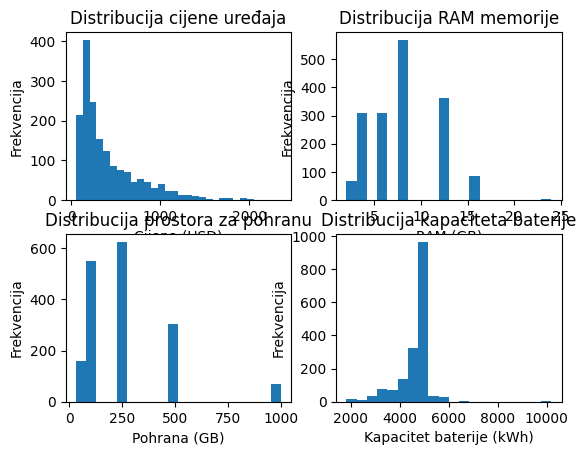

In [22]:
plt.subplot(2, 2, 1)
plt.hist(df['price_usd'], bins=30)
plt.xlabel("Cijena (USD)")
plt.ylabel("Frekvencija")
plt.title("Distribucija cijene uređaja")

plt.subplot(2, 2, 2)
plt.hist(df['ram'], bins=20)
plt.xlabel("RAM (GB)")
plt.ylabel("Frekvencija")
plt.title("Distribucija RAM memorije")

plt.subplot(2, 2, 3)
plt.hist(df['storage'], bins=20)
plt.xlabel("Pohrana (GB)")
plt.ylabel("Frekvencija")
plt.title("Distribucija prostora za pohranu")

plt.subplot(2, 2, 4)
plt.hist(df['battery'], bins=20)
plt.xlabel("Kapacitet baterije (kWh)")
plt.ylabel("Frekvencija")
plt.title("Distribucija kapaciteta baterije")

plt.show()

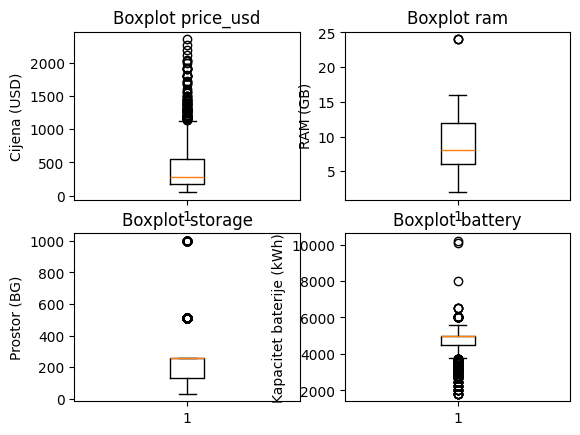

In [23]:
plt.subplot(2, 2, 1)
plt.boxplot(df['price_usd'])
plt.title(f"Boxplot price_usd")
plt.ylabel("Cijena (USD)")

plt.subplot(2, 2, 2)
plt.boxplot(df['ram'])
plt.title(f"Boxplot ram")
plt.ylabel("RAM (GB)")

plt.subplot(2, 2, 3)
plt.boxplot(df['storage'])
plt.title(f"Boxplot storage")
plt.ylabel("Prostor (BG)")

plt.subplot(2, 2, 4)
plt.boxplot(df['battery'])
plt.title(f"Boxplot battery")
plt.ylabel("Kapacitet baterije (kWh)")

plt.show()

Boxplotovi ukazuju na prisutnost ekstremnih vrijednosti, osobito kod cijene i velicine baterije, što je u skladu s prethodno uočenom asimetrijom distribucija.

**Dekspriptivna statistika**

In [24]:
variables = ['price_usd', 'ram', 'storage', 'battery']

desc_stats = pd.DataFrame({
    'Mean': df[variables].mean(),
    'Median': df[variables].median(),
    'Std Dev': df[variables].std(),
    'Min': df[variables].min(),
    'Max': df[variables].max(),
    'Skewness': df[variables].skew(),
    'Kurtosis': df[variables].kurtosis()
})

desc_stats


,Mean,Median,Std Dev,Min,Max,Skewness,Kurtosis
price_usd,419.983156,278.835,361.680703,52.63,2353.82,1.811629,3.736745
ram,7.981265,8.000,3.425618,2.00,24.00,0.716986,0.306426
storage,271.798595,256.000,207.513099,32.00,1000.00,1.806249,3.666509
battery,4657.326698,5000.000,694.689807,1821.00,10200.00,-0.739636,7.021588


Analizom deskriptivne statistike utvrđeno je da varijabla price_usd ima veću standardnu devijaciju u odnosu na ostale varijable, što ukazuje na značajnu varijabilnost cijena uređaja. Medijan je manji od aritmetičke sredine, što potvrđuje pozitivnu asimetriju distribucije cijena.

Varijable ram i storage pokazuju diskretnu strukturu s grupiranjem oko standardnih konfiguracija, što je vidljivo i u histogramima. Njihove vrijednosti skewness upućuju na blagu do umjerenu asimetriju.

Varijabla battery ima manju varijabilnost u usporedbi s cijenom i pohranom, što sugerira da proizvođači koriste slične kapacitete baterija.

Vrijednosti kurtosis kod pojedinih varijabli upućuju na prisutnost ekstremnih vrijednosti, što je u skladu s uočenim outlierima na boxplotovima.